In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

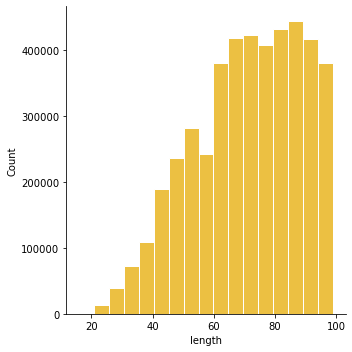

In [3]:
df = pd.read_csv('./pre-calculated_data/smorf_mapped_length.tsv',names=['length'])
sns.displot(data=df,x='length',color='#e6ab02',binwidth=5,edgecolor='white')

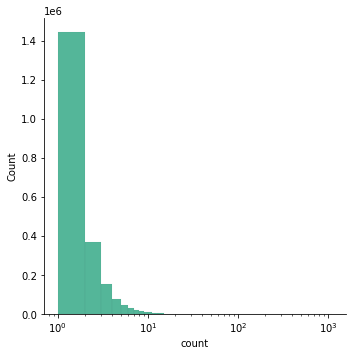

In [5]:
#too large to show here
#df = pd.read_csv('D:\soil\smorf\cluster_count.tsv',sep = '\t',names=['cluster','count','rep','seqs'])
#g=sns.displot(data=df,x='count',color='#1b9e77',binwidth=1)
#g.set(xscale="log")

In [6]:
# plot top 20 pfam
df = pd.read_csv('./pre-calculated_data/all.macrel.mapped.smorfs_dedup_cdd_tcov_family_bg_info_A_C_group.tsv',sep='\t')
df = df.sort_values('GMSC_count',ascending=False)
df = df[:15]
df

,accession,clan,clan_description,PSSM_Id,GMSC_count,GMSC_fraction,short_name,description,PSSM_Length,clan_id,short_description,group
0,8281,HTH,Helix-turn-helix clan,400535,7473,0.005510,Sigma70_r4_2,"Sigma-70, region 4. Region 4 of sigma-70 like ...",54,CL0123,"Sigma-70, region 4",Helix-turn-helix clan
1,4545,HTH,Helix-turn-helix clan,427999,7254,0.005349,Sigma70_r4,"Sigma-70, region 4. Region 4 of sigma-70 like ...",50,CL0123,"Sigma-70, region 4",Helix-turn-helix clan
2,196,HTH,Helix-turn-helix clan,425517,6656,0.004908,GerE,"Bacterial regulatory proteins, luxR family.",57,CL0123,"Bacterial regulatory proteins, luxR family",Helix-turn-helix clan
3,2954,HTH,Helix-turn-helix clan,427077,6232,0.004595,HTH_8,"Bacterial regulatory protein, Fis family.",40,CL0123,"Bacterial regulatory protein, Fis family",Helix-turn-helix clan
4,313,OB,OB fold,278729,5943,0.004382,CSD,'Cold-shock' DNA-binding domain.,66,CL0021,'Cold-shock' DNA-binding domain,OB fold
5,12399,P-loop_NTPase,P-loop containing nucleoside triphosphate hydr...,432527,4812,0.003548,BCA_ABC_TP_C,Branched-chain amino acid ATP-binding cassette...,23,CL0023,Branched-chain amino acid ATP-binding cassette...,P-loop containing nucleoside triphosphate hydr...
6,486,HTH,Helix-turn-helix clan,425712,4154,0.003063,Trans_reg_C,"Transcriptional regulatory protein, C terminal.",77,CL0123,"Transcriptional regulatory protein, C terminal",Helix-turn-helix clan
7,2597,Ubiquitin,Ubiquitin superfamily,396932,4107,0.003028,ThiS,ThiS family. ThiS (thiaminS) is a 66 aa protei...,74,CL0072,ThiS family,Ubiquitin superfamily
8,1381,HTH,Helix-turn-helix clan,396104,3865,0.002850,HTH_3,Helix-turn-helix. This large family of DNA bin...,55,CL0123,Helix-turn-helix,Helix-turn-helix clan
9,550,PP-binding,ACP-like superfamily,425746,3590,0.002647,PP-binding,Phosphopantetheine attachment site. A 4'-phosp...,62,CL0314,Phosphopantetheine attachment site,ACP-like superfamily


C:\Users\admin\anaconda3\lib\_collections_abc.py:832: MatplotlibDeprecationWarning: 
The savefig.jpeg_quality rcparam was deprecated in Matplotlib 3.3 and will be removed two minor releases later.
  self[key] = other[key]
C:\Users\admin\anaconda3\lib\_collections_abc.py:832: MatplotlibDeprecationWarning: 
The savefig.jpeg_quality rcparam was deprecated in Matplotlib 3.3 and will be removed two minor releases later.
  self[key] = other[key]


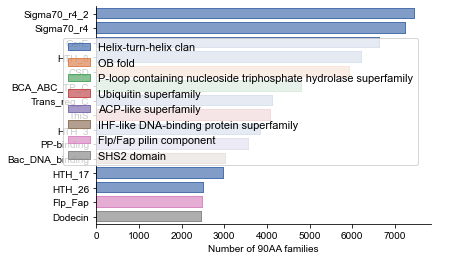

In [8]:
import seaborn.objects as so

f, ax = plt.subplots()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

p = (
    so.Plot(df, x="GMSC_count",y="short_name", color="group")
    .add(so.Bar())
    .label(x="Number of 90AA families", y="",color="")
    .theme({"axes.facecolor": "w", "axes.edgecolor": "black",'axes.linewidth':0.5})
)
p.on(ax).show()

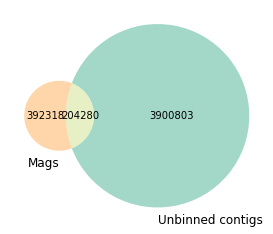

In [9]:
from matplotlib_venn import venn2
venn2(subsets=(392318,3900803,204280),set_labels=('Mags','Unbinned contigs'),set_colors=("#fe9929","#1b9e77"))

In [10]:
df = pd.read_csv('./pre-calculated_data/smorf_tax.csv')
df

,Taxonomy,Super_kingdom,Phylum,Class,Order,Family,Genus,Species,No_rank
0,mags,0.000642,0.000872,0.004208,0.031135,0.257661,0.692166,0.007081,0.006235
1,contigs,0.090718,0.060234,0.075997,0.146570,0.323812,0.254983,0.047589,0.000097
2,all,0.078743,0.052327,0.066330,0.130710,0.314031,0.310158,0.047073,0.000628


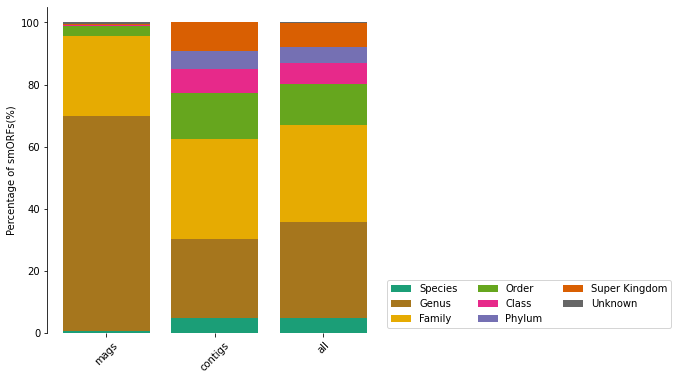

In [11]:
fig, ax = plt.subplots(figsize=(6,6))
x = df['Taxonomy']
y8 = df['No_rank'] *100
y7 = df['Super_kingdom'] *100
y6 = df['Phylum'] *100
y5 = df['Class'] *100
y4 = df['Order'] *100
y3 = df['Family'] *100
y2 = df['Genus'] *100
y1 = df['Species'] *100

plt.bar(x,y1,color='#1b9e77',label='Species')
plt.bar(x,y2,bottom=y1,color='#a6761d',label='Genus')
plt.bar(x,y3,bottom=y1+y2,color='#e6ab02',label='Family')
plt.bar(x,y4,bottom=y1+y2+y3,color='#66a61e',label='Order')
plt.bar(x,y5,bottom=y1+y2+y3+y4,color='#e7298a',label='Class')
plt.bar(x,y6,bottom=y1+y2+y3+y4+y5,color='#7570b3',label='Phylum')
plt.bar(x,y7,bottom=y1+y2+y3+y4+y5+y6,color='#d95f02',label='Super Kingdom')
plt.bar(x,y8,bottom=y1+y2+y3+y4+y5+y6+y7,color='#666666',label='Unknown')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.xticks(rotation=45)
plt.ylabel('Percentage of smORFs(%)')
plt.legend(loc=3,bbox_to_anchor=(1,0),ncol=3)

In [13]:
df = pd.read_csv('./pre-calculated_data/contig_selected.tsv',sep = '\t',header=None,names=['contig','length','cp','sample'])
df

,contig,length,cp,sample
0,cpsnj15_contig_69220,21763,0,cpsnj15
1,sample24_contig_100860,51165,2,sample24
2,snj16_contig_37626,109825,5,snj16
3,sample18_contig_7034,215209,0,sample18
4,sample19_contig_65143,134477,6,sample19
...,...,...,...,...
13690,snj13_contig_71399,81564,4,snj13
13691,sample1_contig_119693,20643,0,sample1
13692,sample27_contig_92478,13513,0,sample27
13693,cpsnj16_contig_11795,12712,0,cpsnj16


In [14]:
sum_value1 = df.groupby('sample')['length'].sum()
sum_value2 = df.groupby('sample')['cp'].sum()
 
ratio = sum_value2/(sum_value1/1000000)
 
result = pd.DataFrame({
    'Sum_length': sum_value1,
    'Sum_cp': sum_value2,
    'Ratio': ratio
})
result['Type'] = 'not plasmid'
result

,Sum_length,Sum_cp,Ratio,Type
sample,,,,
cpsnj01,7114618,235,33.030586,not plasmid
cpsnj02,10527758,298,28.306122,not plasmid
cpsnj03,11294263,276,24.437185,not plasmid
cpsnj04,13739213,381,27.730846,not plasmid
cpsnj08,10786239,345,31.985199,not plasmid
cpsnj09,21167039,632,29.857743,not plasmid
cpsnj10,12874844,330,25.631379,not plasmid
cpsnj11,10250320,280,27.316220,not plasmid
cpsnj13,9340928,297,31.795556,not plasmid


In [15]:
df = pd.read_csv('./pre-calculated_data/contigs_plasmid_all_cpnumber.tsv',sep = '\t',header=None,names=['contig','circ','length','score','tax','sample','cp'])
df

,contig,circ,length,score,tax,sample,cp
0,cpsnj01_contig_62473,linear,21665,0.9939,12 # class # Bacilli,cpsnj01,2
1,cpsnj01_contig_68824,linear,47631,0.9918,96 # family # Rhizobiaceae,cpsnj01,3
2,cpsnj01_contig_56426,linear,26475,0.9918,96 # family # Rhizobiaceae,cpsnj01,3
3,cpsnj01_contig_60924,linear,78135,0.9899,96 # family # Rhizobiaceae,cpsnj01,2
4,cpsnj01_contig_75747,linear,14166,0.9892,25709 # genus # Microvirga,cpsnj01,3
...,...,...,...,...,...,...,...
13690,snj20_contig_12899,linear,16232,0.9504,90 # class # Alphaproteobacteria,snj20,0
13691,snj20_contig_79001,linear,30226,0.9502,3 # phylum # Pseudomonadota,snj20,0
13692,snj20_contig_3784,linear,70089,0.9502,66 # family # Burkholderiaceae,snj20,0
13693,snj20_contig_61622,linear,21792,0.9502,56 # order # Burkholderiales,snj20,1


In [16]:
sum_value1 = df.groupby('sample')['length'].sum()
sum_value2 = df.groupby('sample')['cp'].sum()
 
ratio = sum_value2/(sum_value1/1000000)
 
result_plasmid = pd.DataFrame({
    'Sum_length': sum_value1,
    'Sum_cp': sum_value2,
    'Ratio': ratio
})
result_plasmid['Type'] = 'plasmid'
result_plasmid

,Sum_length,Sum_cp,Ratio,Type
sample,,,,
cpsnj01,14659413,778,53.071702,plasmid
cpsnj02,7173492,325,45.305689,plasmid
cpsnj03,5214557,223,42.764898,plasmid
cpsnj04,9467308,318,33.589274,plasmid
cpsnj08,9944002,541,54.404655,plasmid
cpsnj09,9066342,530,58.457976,plasmid
cpsnj10,11845199,760,64.161016,plasmid
cpsnj11,11038668,465,42.124648,plasmid
cpsnj13,7121898,390,54.760683,plasmid


In [17]:
result_all = pd.concat([result,result_plasmid])
result_all

,Sum_length,Sum_cp,Ratio,Type
sample,,,,
cpsnj01,7114618,235,33.030586,not plasmid
cpsnj02,10527758,298,28.306122,not plasmid
cpsnj03,11294263,276,24.437185,not plasmid
cpsnj04,13739213,381,27.730846,not plasmid
cpsnj08,10786239,345,31.985199,not plasmid
...,...,...,...,...
snj14,8492859,429,50.513025,plasmid
snj15,6420955,242,37.689098,plasmid
snj16,7391498,309,41.804787,plasmid


In [19]:
import scipy.stats as stats
bacteria = result['Ratio'].tolist()
plasmid = result_plasmid['Ratio'].tolist()
statistic,pvalue=stats.mannwhitneyu(bacteria,plasmid,alternative = 'two-sided')
pvalue

1.1704099218478365e-17

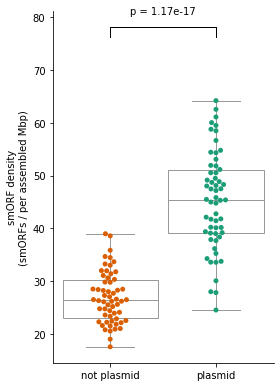

In [21]:
fig = plt.figure(figsize=(4, 5.5))
colors= ['#d95f02','#1b9e77']
sns.set_palette(sns.color_palette(colors))

ax=sns.boxplot(
            data=result_all,
            x='Type',
            y='Ratio',
            showfliers=False,
            color='white',width=0.9)

sns.swarmplot(
              data=result_all,
              x='Type',
              y='Ratio',
              s=5,
              hue='Type' 
              )

x1, x2 = 0, 1
y,h = result_all["Ratio"].mean()+40,2

#绘制横线位置
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c="k") 
#添加P值
plt.text((x1+x2)*.5, y+h+2, 'p = 1.17e-17', ha='center', va='bottom', color="k")
#plt.legend(loc=3,bbox_to_anchor=(0,1.1),ncol=2)

#plt.ylim([0,400])
ax.set_xlabel('')
ax.set_ylabel('smORF density\n(smORFs / per assembled Mbp)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

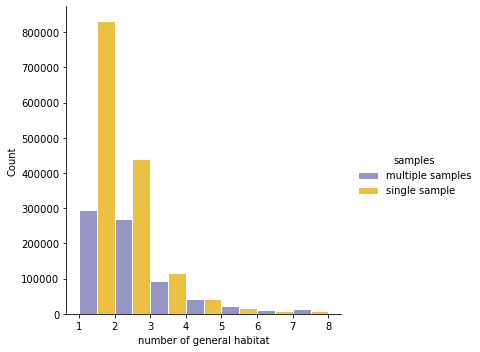

In [26]:
df = pd.read_csv('./pre-calculated_data/cluster_habitat_general_sample.tsv.xz',compression='xz',sep='\t',names=['cluster','habitat','number of habitat','general','number of general habitat','samples'])
sns.displot(data=df,x='number of general habitat',binwidth=1,edgecolor='white',hue="samples",multiple="dodge",palette=['#7570b3','#e6ab02'])

/home/huayuqin/miniconda3/envs/soil/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


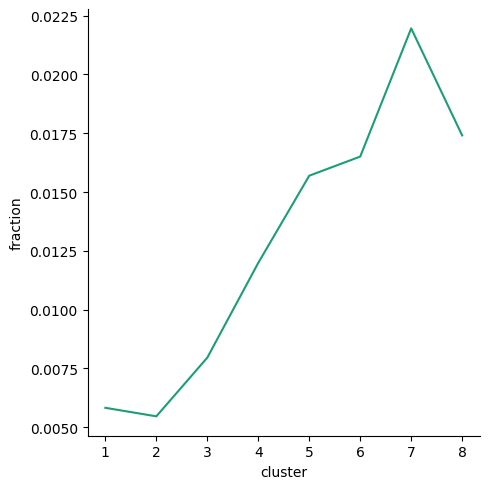

In [2]:
df = pd.read_csv('./pre-calculated_data/habitat_plasmid_fraction_general.tsv',sep='\t',names=['cluster','fraction'])
sns.relplot(data=df, x="cluster", y="fraction",kind="line",color='#1b9e77')

In [28]:
stats.pearsonr(df['cluster'],df['fraction'])

PearsonRResult(statistic=0.9342454633744208, pvalue=0.0006761601535733251)

In [30]:
df = pd.read_csv('./pre-calculated_data/cluster_habitat_general.tsv.xz',compression='xz',sep = '\t',names=['cluster','habitat','all_number','general','general_num'])
df

,cluster,habitat,all_number,general,general_num
0,Cluster 0,"plant associated,soil,water associated",3,"aquatic,soil/plant",2
1,Cluster 1,"built environment,plant associated,river assoc...",6,"anthropogenic,aquatic,soil/plant",3
2,Cluster 2,"plant associated,soil,water associated",3,"aquatic,soil/plant",2
3,Cluster 3,"plant associated,soil,water associated",3,"aquatic,soil/plant",2
4,Cluster 4,"activated sludge,built environment,groundwater...",8,"anthropogenic,aquatic,soil/plant",3
...,...,...,...,...,...
2206896,Cluster 2206896,soil,1,soil/plant,1
2206897,Cluster 2206897,chicken gut,1,other animal,1
2206898,Cluster 2206898,"plant associated,soil,water associated",3,"aquatic,soil/plant",2
2206899,Cluster 2206899,"marine,plant associated,soil",3,"aquatic,soil/plant",2


<ipython-input-32-96fe960e84e2>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=all_counts.values, y=all_counts.index, palette="viridis")


Text(0, 0.5, '')

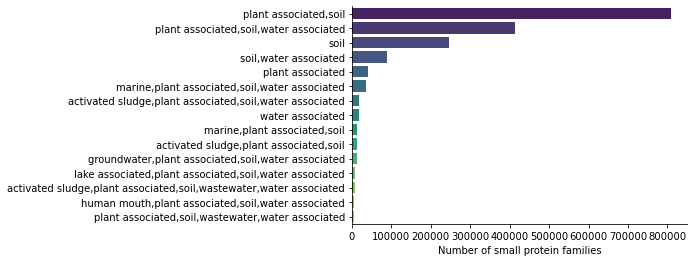

In [32]:
fig = plt.subplots()
all_counts = df['habitat'].value_counts().head(15)
ax = sns.barplot(x=all_counts.values, y=all_counts.index, palette="viridis")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('Number of small protein families')
ax.set_ylabel('')

In [33]:
general_expanded = df['general'].str.split(',', expand=True).stack().reset_index(drop=True)
general_expanded

0                aquatic
1             soil/plant
2          anthropogenic
3                aquatic
4             soil/plant
               ...      
3971198          aquatic
3971199       soil/plant
3971200          aquatic
3971201       soil/plant
3971202       soil/plant
Length: 3971203, dtype: object

In [34]:
general_counts = general_expanded.value_counts()
general_counts

soil/plant       2167918
aquatic          1009258
anthropogenic     367046
other             178524
other animal      106504
other human        74947
mammal gut         37761
human gut          29245
Name: count, dtype: int64

Text(0, 0.5, '')

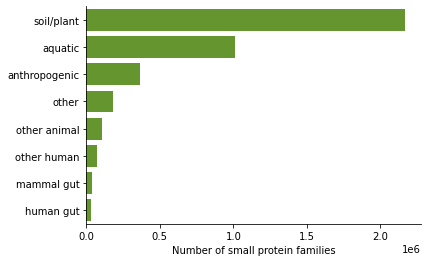

In [35]:
fig = plt.subplots()
ax = sns.barplot(x=general_counts.values, y=general_counts.index,color='#66a61e')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('Number of small protein families')
ax.set_ylabel('')